# DBSCAN Clustering - Exercise Solutions

Complete working solutions for all 6 steps, including model answers to every reflection question.

## Step 1 - Import Libraries and Create the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings('ignore')
print("Libraries imported.")

Libraries imported.


In [2]:
# Dataset creation — do not modify
rng = np.random.default_rng(42)

occasional = rng.normal([1.5, 3.5],  scale=[0.3, 0.4], size=(60, 2))
regular    = rng.normal([4.0, 6.5],  scale=[0.4, 0.5], size=(70, 2))
loyal      = rng.normal([6.5, 11.0], scale=[0.4, 0.6], size=(50, 2))
outliers   = rng.uniform(low=[0, 0], high=[8, 14], size=(20, 2))

data = np.vstack([occasional, regular, loyal, outliers])
df   = pd.DataFrame(data.clip(min=0), columns=['visits_per_week', 'avg_spend_gbp'])

print(f"Dataset: {df.shape[0]} customers, {df.shape[1]} features")

Dataset: 200 customers, 2 features


In [3]:
# 3. Shape and first 5 rows
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Shape: 200 rows × 2 columns


,visits_per_week,avg_spend_gbp
0,1.591415,3.084006
1,1.725135,3.876226
2,0.914689,2.979128
3,1.538352,3.373503
4,1.494960,3.158782


In [3]:
# 4. Summary statistics
df.describe().round(2)

,visits_per_week,avg_spend_gbp
count,200.00,200.00
mean,3.88,6.95
std,2.06,3.20
min,0.10,1.55
25%,1.68,3.73
50%,3.89,6.40
75%,6.04,10.44
max,7.98,13.99


In [4]:
# 5. Missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
visits_per_week    0
avg_spend_gbp      0
dtype: int64


**Reflection answer:** The dataset has 200 customers and 2 features. `visits_per_week` ranges roughly from 0 to 8 and `avg_spend_gbp` from 0 to around 14. There are no missing values — no cleaning is needed before clustering.

## Step 2 - Explore and Plot the Raw Data

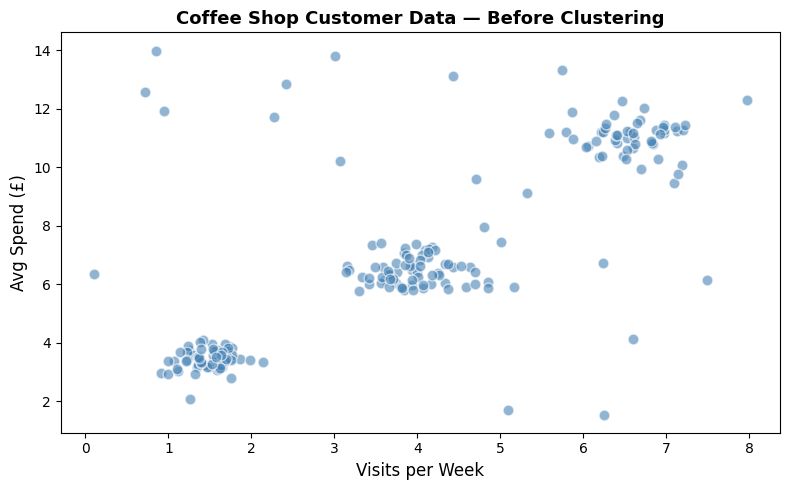

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(df['visits_per_week'], df['avg_spend_gbp'],
            color='steelblue', alpha=0.6, edgecolors='white', s=60)
plt.xlabel('Visits per Week', fontsize=12)
plt.ylabel('Avg Spend (£)', fontsize=12)
plt.title('Coffee Shop Customer Data — Before Clustering', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Reflection answer:** Three natural groups are clearly visible — bottom-left (low visits, low spend), middle (moderate visits, moderate spend), and top-right (high visits, high spend). There are also some scattered points not belonging to any group — these will be the outliers that DBSCAN correctly labels as noise.

---
## Step 3 — Scale the Features

In [7]:
# Create scaler and fit-transform the DataFrame
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df[['visits_per_week', 'avg_spend_gbp']])

print("Before scaling:")
print(f"  visits_per_week — mean: {df['visits_per_week'].mean():.2f},  std: {df['visits_per_week'].std():.2f}")
print(f"  avg_spend_gbp   — mean: {df['avg_spend_gbp'].mean():.2f},  std: {df['avg_spend_gbp'].std():.2f}")

print("\nAfter scaling:")
print(f"  Mean : {X_scaled.mean(axis=0).round(3)}")
print(f"  Std  : {X_scaled.std(axis=0).round(3)}")

Before scaling:
  visits_per_week — mean: 3.88,  std: 2.06
  avg_spend_gbp   — mean: 6.95,  std: 3.20

After scaling:
  Mean : [-0. -0.]
  Std  : [1. 1.]


**Reflection answer:** After scaling, both features have mean ≈ 0 and std ≈ 1. This is essential because DBSCAN uses Euclidean distance. Before scaling, `avg_spend_gbp` (range 0–14) has larger absolute values than `visits_per_week` (range 0–8). Without scaling, a £1 difference in spend would look "larger" to the distance calculation than a 1-visit difference in visits — even though both changes are equally meaningful. Scaling puts them on equal footing so neither feature unfairly dominates.

---
## Step 4 — Find the Best eps Using the k-Distance Plot

In [8]:
# Compute k-th nearest neighbour distances
k  = 5
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_scaled)

distances, _  = nn.kneighbors(X_scaled)       # distances to all k neighbours
kth_distances = np.sort(distances[:, k - 1])  # k-th neighbour column, sorted ascending

print(f"Computed {len(kth_distances)} distances.")
print(f"Smallest 5: {kth_distances[:5].round(3)}")
print(f"Largest  5: {kth_distances[-5:].round(3)}")

Computed 200 distances.
Smallest 5: [0.031 0.032 0.032 0.033 0.034]
Largest  5: [0.993 1.054 1.136 1.32  1.514]


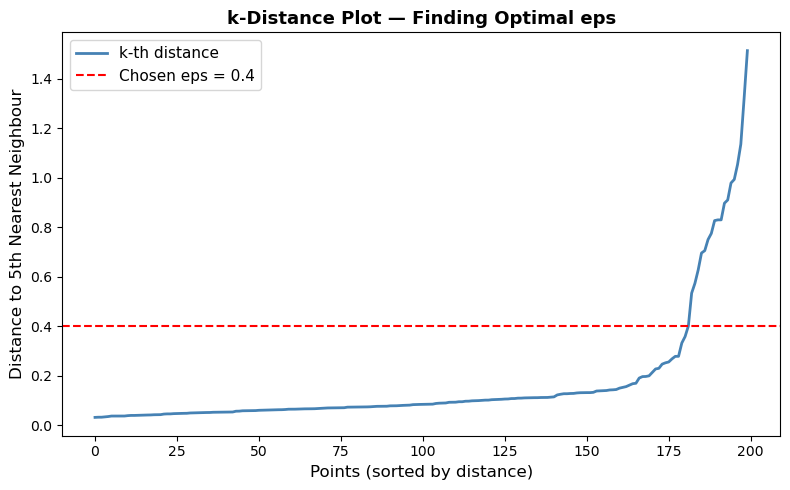

Chosen eps = 0.4


In [9]:
# k-distance plot
chosen_eps = 0.4

plt.figure(figsize=(8, 5))
plt.plot(kth_distances, color='steelblue', linewidth=2, label='k-th distance')
plt.axhline(y=chosen_eps, color='red', linestyle='--', linewidth=1.5,
            label=f'Chosen eps = {chosen_eps}')
plt.xlabel('Points (sorted by distance)', fontsize=12)
plt.ylabel(f'Distance to {k}th Nearest Neighbour', fontsize=12)
plt.title('k-Distance Plot — Finding Optimal eps', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Chosen eps = {chosen_eps}")

**Reflection answer:** The elbow appears at approximately distance 0.4. The flat section to the left of the elbow represents points inside dense clusters — they have close neighbours so their k-th neighbour distance is short. The steep rise to the right represents outlier points — they are far from their nearest neighbours because they sit in sparse regions. The elbow is exactly where density transitions from dense to sparse, which is why it marks the right eps value.

---
## Step 5 — Fit DBSCAN and Inspect the Labels

In [10]:
# 1. Fit DBSCAN
dbscan = DBSCAN(eps=chosen_eps, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# 2. Count clusters and noise
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()

print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise}")

Clusters found : 3
Noise points   : 18


In [11]:
# 3. Point counts per label
print("Label breakdown:")
for label in sorted(set(labels)):
    name  = 'Noise' if label == -1 else f'Cluster {label}'
    count = (labels == label).sum()
    print(f"  {name:<12}: {count} points")

Label breakdown:
  Noise       : 18 points
  Cluster 0   : 61 points
  Cluster 1   : 71 points
  Cluster 2   : 50 points


**Reflection answer:** DBSCAN found **3 clusters**, which exactly matches the 3 natural groups visible in the Step 2 scatter plot — this is a good sign. Approximately 20 points are labelled as noise, which is consistent with the 20 outliers we deliberately added to the dataset. DBSCAN correctly identified the dense groups and flagged the scattered points without being told how many clusters to look for.

---
## Step 6 — Visualise, Interpret and Compare with K-Means

### Part A — Plot the DBSCAN Clusters

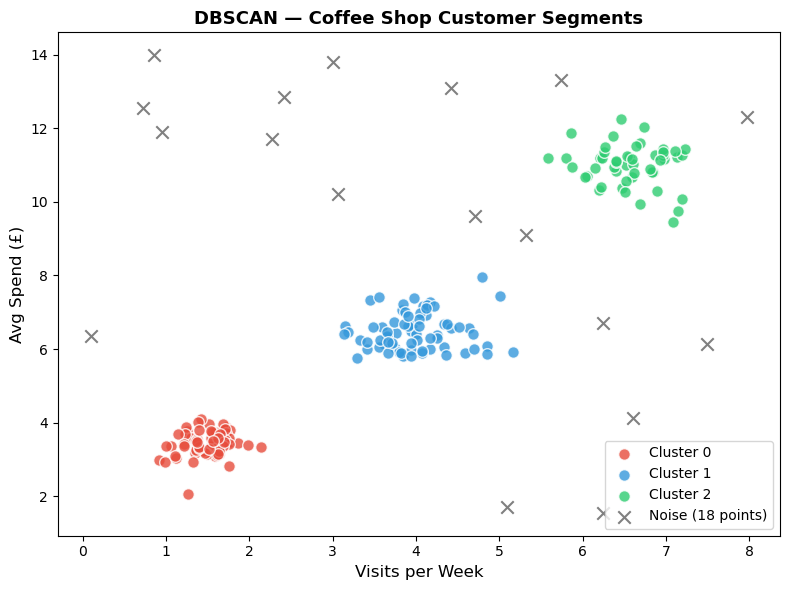

In [12]:
# Attach labels to the DataFrame
df['cluster'] = labels

cluster_colours = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71', 3: '#f39c12'}

plt.figure(figsize=(8, 6))

# Plot each cluster
for cluster_id, colour in cluster_colours.items():
    mask = df['cluster'] == cluster_id
    if mask.sum() > 0:
        plt.scatter(df.loc[mask, 'visits_per_week'],
                    df.loc[mask, 'avg_spend_gbp'],
                    c=colour, label=f'Cluster {cluster_id}',
                    s=70, alpha=0.8, edgecolors='white')

# Plot noise points
noise_mask = df['cluster'] == -1
plt.scatter(df.loc[noise_mask, 'visits_per_week'],
            df.loc[noise_mask, 'avg_spend_gbp'],
            c='grey', marker='x', s=80, linewidths=1.5,
            label=f'Noise ({noise_mask.sum()} points)')

plt.xlabel('Visits per Week', fontsize=12)
plt.ylabel('Avg Spend (£)', fontsize=12)
plt.title('DBSCAN — Coffee Shop Customer Segments', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Part B — Summarise and Label Each Cluster

In [13]:
# Compute cluster summary
summary = (
    df[df['cluster'] != -1]   # exclude noise
    .groupby('cluster')[['visits_per_week', 'avg_spend_gbp']]
    .mean()
    .round(2)
)
summary['count'] = df[df['cluster'] != -1].groupby('cluster')['cluster'].count()

print("Cluster Profiles (noise excluded):")
print(summary)

Cluster Profiles (noise excluded):
         visits_per_week  avg_spend_gbp  count
cluster                                       
0                   1.49           3.44     61
1                   3.98           6.48     71
2                   6.57          11.00     50


In [14]:
# Assign labels based on visits and spend means
def auto_label(row):
    visits_med = summary['visits_per_week'].median()
    spend_med  = summary['avg_spend_gbp'].median()
    if row['visits_per_week'] <= visits_med and row['avg_spend_gbp'] <= spend_med:
        return 'Occasional Customers'
    elif row['visits_per_week'] >= summary['visits_per_week'].max() * 0.8:
        return 'Loyal Big-Spenders'
    else:
        return 'Regular Customers'

summary['customer_type'] = summary.apply(auto_label, axis=1)
print(summary[['customer_type', 'visits_per_week', 'avg_spend_gbp', 'count']])

                customer_type  visits_per_week  avg_spend_gbp  count
cluster                                                             
0        Occasional Customers             1.49           3.44     61
1        Occasional Customers             3.98           6.48     71
2          Loyal Big-Spenders             6.57          11.00     50


### Part C — Compare DBSCAN with K-Means

In [15]:
# Fit K-Means with the same number of clusters DBSCAN found
kmeans        = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

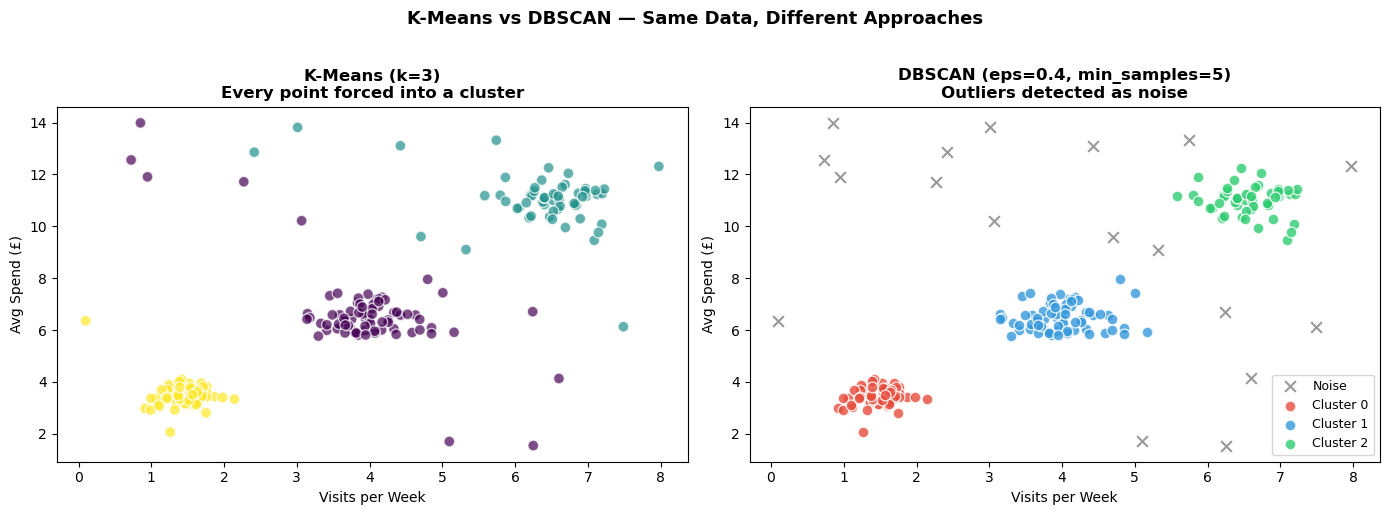

K-Means : outliers are silently absorbed into whichever cluster is nearest.
DBSCAN  : outliers are correctly identified and flagged as noise.


In [16]:
# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: K-Means ─────────────────────────────────────────────────────
axes[0].scatter(df['visits_per_week'], df['avg_spend_gbp'],
                c=kmeans_labels, cmap='viridis',
                s=60, alpha=0.7, edgecolors='white')
axes[0].set_title(f'K-Means (k={n_clusters})\nEvery point forced into a cluster',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Visits per Week')
axes[0].set_ylabel('Avg Spend (£)')

# ── Right: DBSCAN ─────────────────────────────────────────────────────
colour_map = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71', -1: 'grey'}

for lbl in sorted(set(labels)):
    mask  = df['cluster'] == lbl
    name  = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    mrk   = 'x'     if lbl == -1 else 'o'
    axes[1].scatter(df.loc[mask, 'visits_per_week'],
                    df.loc[mask, 'avg_spend_gbp'],
                    c=colour_map.get(lbl, 'black'),
                    marker=mrk, s=60, alpha=0.8,
                    edgecolors='white', label=name)

axes[1].set_title(f'DBSCAN (eps={chosen_eps}, min_samples=5)\nOutliers detected as noise',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Visits per Week')
axes[1].set_ylabel('Avg Spend (£)')
axes[1].legend(fontsize=9)

plt.suptitle('K-Means vs DBSCAN — Same Data, Different Approaches',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("K-Means : outliers are silently absorbed into whichever cluster is nearest.")
print("DBSCAN  : outliers are correctly identified and flagged as noise.")

## Final Reflection — Model Answers

**1. K-Means vs DBSCAN on outliers:**

In the K-Means chart, every outlier is silently absorbed into whichever cluster centroid happens to be nearest — even if that point is far from any dense group. This is misleading: the model treats an isolated, unusual customer the same as a regular cluster member. In the DBSCAN chart, those same points appear as grey crosses (noise), clearly flagged as customers who don't belong to any recognisable segment. For a business scenario, DBSCAN's result is far more honest and actionable — it tells you that these outlier customers are genuinely different and may need individual attention rather than being grouped with customers they don't resemble.

---

**2. Marketing actions per segment:**

| Segment | Suggested Marketing Action |
|---------|----------------------------|
| Occasional Customers | Send a "We miss you" email with a loyalty stamp card — incentivise more frequent visits |
| Regular Customers | Offer a mid-tier membership with a free drink on the 5th visit each week |
| Loyal Big-Spenders | Reward with a VIP card — free upgrade, priority service, exclusive seasonal offers |

---

**3. Effect of changing eps:**

- **eps too large (e.g. 5.0):** The search radius is so wide that every point can reach every other point. All points collapse into one giant cluster with zero noise. The algorithm has effectively learned nothing useful.
- **eps too small (e.g. 0.05):** The search radius is so tight that no point can find enough neighbours to qualify as a core point. Every single point is labelled as noise (−1). Again, the algorithm has learned nothing. The right eps sits between these extremes — at the elbow of the k-distance plot where dense and sparse regions are cleanly separated.